# Depth–Time Series


This notebook examines the **temporal evolution of the vertical structure of ocean biogeochemical and physical variables anomalies** using depth–time diagrams across model simulations and observational products. It provides a configurable workflow for selecting variables, datasets, experiments, biomes, depth ranges, and temporal periods; loading and preparing the corresponding data; calculating anomalies and regional averages; and visualizing how subsurface conditions evolve through time.

The analysis is particularly useful for investigating **interannual and ENSO-related variability in the tropical oceans**, where changes in upper-ocean circulation and subsurface structure can strongly influence physical and biogeochemical conditions. ENSO events can also be overlaid on the depth–time diagrams to relate vertical anomalies to El Niño or La Niña periods.

The notebook follows four main stages:

1. **Package and configuration setup** – Load the required analysis, plotting, and project configuration utilities.
2. **Data request configuration** – Select variables, datasets/experiments, observational sources, biomes, depth ranges, and optional derived physical quantities.
3. **Data loading and preparation** – Load and preprocess the requested datasets, calculate derived variables where requested, remove the climatological seasonal cycle to obtain anomalies, and calculate biome-averaged vertical time series.
4. **Visualization** – Generate depth–time diagrams of anomalies for the selected biome and datasets, with optional identification of El Niño or La Niña periods.

## Biomes

The biomes defined here are Pacific Equatorial (PEQ), PEQ East and West (PEQ-E, PEQ-W), and Atlantic Equatorial (AEQ). The latitude range is configurable.


## Optional configurations

1. **`calculate_ekman`** – Optionally calculate **Ekman transport** when the required wind-stress variables are available. The derived Ekman field can then be included in the depth–time analysis.

2. **`calculate_density`** – Optionally calculate **seawater density** when the required temperature and salinity fields are available. The resulting density field can then be analysed in the same depth–time framework.

3. **ENSO event highlighting** – ONI-based El Niño and La Niña events can be identified and optionally overlaid on the depth–time plots. This makes it possible to directly relate vertical anomalies to the timing of ENSO events.


### Package and configuration setup

In [8]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

import numpy as np
import configs
from prepare import (prepare_data_for_analysis, 
                    load_ONI,
                    get_ekman,
                    get_density,
                     calculate_climatology, 
                     get_enso_events,
                     experiment_finder,
                     take_area_average,
                     create_eq_biomes)

from modules.plotting.module_plot_2D import plot_depth_vs_time_biomeavg
from modules.analysis.module_data_load import load_biomes
from modules.data_info.module_data_info import biomes_module


In [3]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx
ENSO = configs.ENSO
contourf = configs.contourf

### User configs

In [ ]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'
biomes_directory =  "/space/hall7/sitestore/eccc/crd/cccma/users/rsa001/big_store/AI/FGCO2/data/biomes" 

assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = ['uas','vas','tauu','tauv', 'wo', 'uo']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']

 ## this could be a dictionary for each variable as they might have different sources or one source for all variables.
obs_source = {'uas': 'ERA5','vas': 'ERA5', 'wo': 'SODA', 'uo': 'SODA'}
 
calculate_ekman: bool = True
calculate_density: bool = True

### Data Loading

In [5]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            target_levels=model_levels,
                            verbose = True)

tauu observation does not exist
tauv observation does not exist

observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/observation/ERA5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/observation/ERA5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/wo/observation/SODA
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/observation/SODA

model directories: 

uas assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/assimilation/CanESM5-CanOE_1
uas historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uas/historical/CanESM5-CanOE
vas assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vas/assimilation/CanESM5-CanOE_1
vas historical: 
/spa

In [9]:
bms_info = biomes_module(biomes_directory)
bms_dict = bms_info.data_dict['biomes']
bms_dir  = bms_dict['dir']
bms_file = bms_dict['file']
bms_dict_plot = bms_info.dict_biomes_plot
nbms = 17
bms_labels = [bms_info.biomes_dict[ii]['label'] for ii in np.arange(nbms)+1]

biomes = load_biomes(f'{bms_dir}',
                     f'{bms_file}') * mask_ocean_surface

mask_biomes = create_eq_biomes(biomes, lat_max = 2, lat_min = -2)


loading global ocean biomes..
done


In [10]:
ONI_dict = load_ONI(experiment_list, 
                    model_list, 
                    assimilation_BGC_run_id,
                    CanOE_assimilation_BGC_run_id,
                    obs_source='ERSST')

ElNino_dict, LaNina_dict = get_enso_events(ONI_dict)


In [11]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [12]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_em_data:
        for exp in dict_em_data[var]:
            print(f'{var} {exp}')
            display(dict_em_data[var][exp].data)




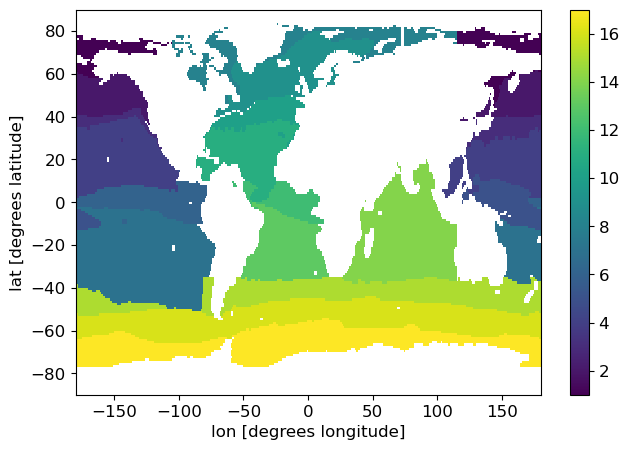

In [13]:
idisplay=True

if idisplay:
    (biomes.MeanBiomes * mask_ocean_surface ).where(biomes.MeanBiomes * mask_ocean_surface > 0).plot()


### Data Prep

In [14]:
if calculate_ekman:
    dict_em_data = get_ekman(dict_em_data)

if calculate_density: 
    dict_em_data = get_density(dict_em_data)

so or thetao does not exist. Density cannot be calculated.


In [15]:
dict_em_clim, dict_em_anom = calculate_climatology(dict_em_data,
                                                   y0_base=None,
                                                   y1_base=None,
                                                   return_anomaly=True,
                                                   center_on_zero=True)

dict_em_anom =  take_area_average(dict_em_anom, mask_biomes)                                               

calculating uas CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...


done.
calculating uas CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating uas CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating uas CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done.
calculating uas obs climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating vas CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done.
calculating vas obs climatology over 1980 - 2023 ...
done.
calculating tauu CanESM5-CMOC_assimilation climatology over 1958 - 2023 ...
done.
calculating tauu CanESM5-CMOC_historical climatology over 1958 - 2023 ...
done.
calculating tauv CanESM5-CMOC_assimilation climatology over 1958 - 2023 ...
done.
calculating tauv CanESM5-CMOC_historical climatology over 1958 - 

### Plots

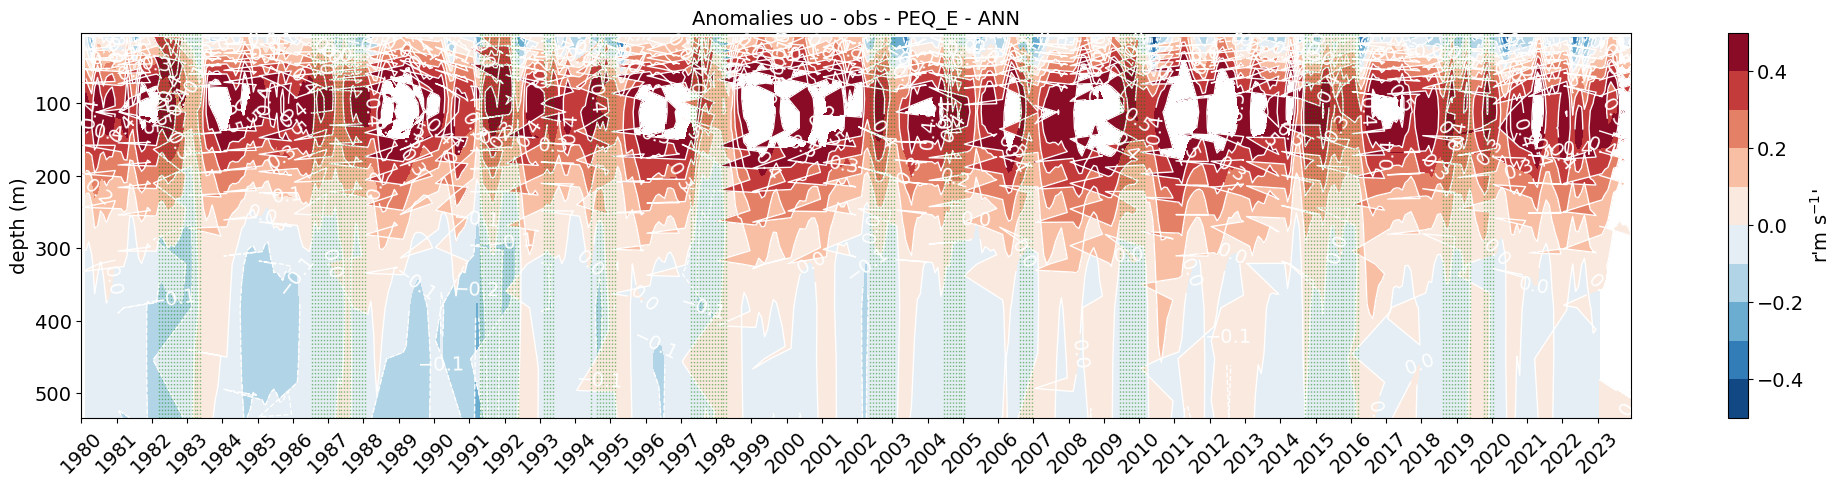

In [28]:
var = 'uo'

model_experiment = ['observation']
season_to_plot = 'ANN'



title = f'Anomalies {var}'
bms_label =  'PEQ_E'
colorbar_label = units[var]
lev_range = 600

ds_dicts = dict_em_anom[var]
ds_list = experiment_finder(dict_em_data[var], model_experiment)

ElNino = ElNino_dict["obs"]
# LaNina = LaNina_dict["obs"]

plot_depth_vs_time_biomeavg(
    ds_list=ds_list,
    ds_dicts=ds_dicts,
    biome=bms_label,
    title=title,
    figsize=(25,5), 
    cmap = 'RdBu_r',
    contourf_levels=contourf.get(var),
    colorbar_label=colorbar_label,
    season = "ANN",
    lev_range=lev_range,
    monthly_res= True,
    ELNINO_years= ElNino,
    ELNINO_color='g'
    # LANINA_years= LaNina,
)
